Task 7. Feature Matching Across Photos   

Take a 6th photo right now of the same desk scene from a different angle. Run ORB feature matching between the two objects photos. Report how many good matches you get and describe which two real objects produced the strongest match. 

In [1]:
import cv2
import matplotlib.pyplot as plt

In [7]:
img1 = cv2.imread("raw_captures\Object.jpeg")
img2 = cv2.imread("raw_captures\Object1.jpeg")

gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

In [8]:
orb = cv2.ORB_create(nfeatures=2000)

In [9]:
kp1, des1 = orb.detectAndCompute(gray1, None)
kp2, des2 = orb.detectAndCompute(gray2, None)

In [10]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING)

matches = bf.knnMatch(des1, des2, k=2)

In [11]:
good_matches = []

for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

In [12]:
print("Good Matches :", len(good_matches))

Good Matches : 81


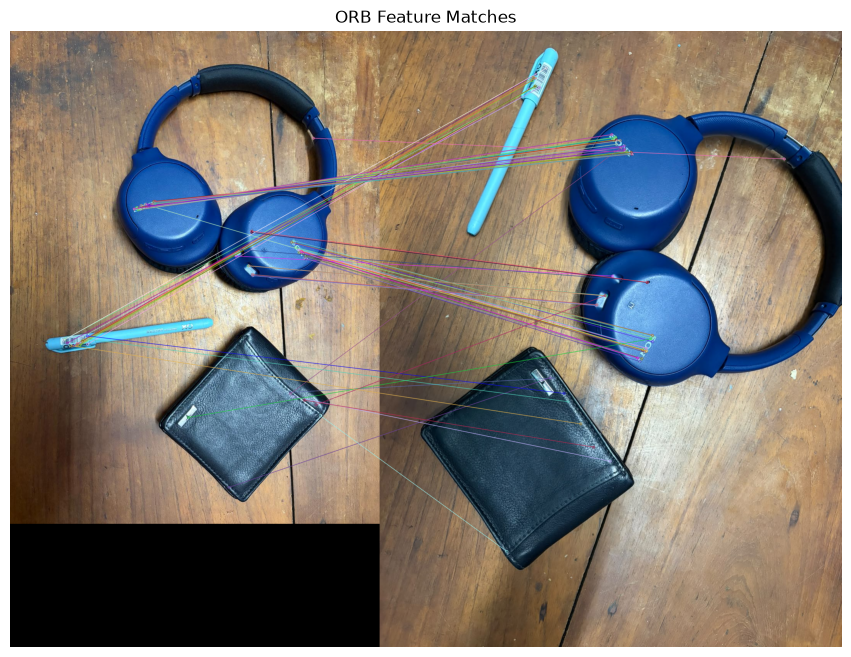

In [13]:
matched = cv2.drawMatches(
    img1,
    kp1,
    img2,
    kp2,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(18,8))
plt.imshow(cv2.cvtColor(matched, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.axis("off")
plt.show()

ORB detected 81 good matches between the two objects photos. The headset produced the strongest feature matches, with most of the matched keypoints appearing on the ear cups, headband, and other textured or high-contrast regions. The pen produced fewer matches because it has a simple, elongated shape with fewer distinctive corners. The man purse also produced relatively fewer matches due to its smoother surface and limited texture. Overall, the headset was the most reliable object for feature matching because it contained more unique visual features that remained detectable even when the viewing angle changed.